<a href="https://colab.research.google.com/github/kjahan/nlp_tips_and_trick/blob/main/notebooks/korean_docs_translator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MT/LLM for Translation

Imagine we have a scanned doc in Korean (birth certificate). We want to translate it to Enlglish.

## Load test images

In [1]:
!mkdir images

In [2]:
import matplotlib.pyplot as plt


## Load image

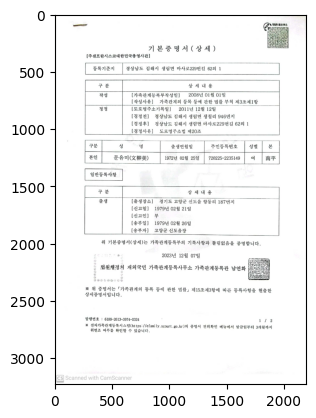

In [4]:
# Open the image file
img_1 = plt.imread("images/korean_img_1.jpg")

# Display the image
plt.imshow(img_1)
plt.show()

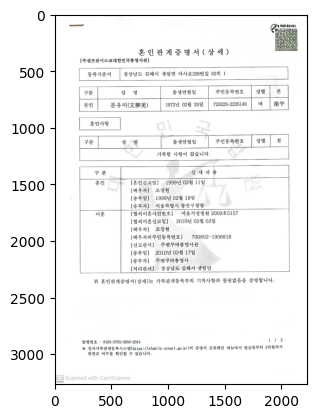

In [5]:
# Open the image file
img_2 = plt.imread("images/korean_img_2.jpg")

# Display the image
plt.imshow(img_2)
plt.show()

In [16]:
images = [img_1, img_2]

## Install Terrasect

In [6]:
! apt install tesseract-ocr
! apt install libtesseract-dev
! pip install Pillow
! pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 24 not upgraded.
Need to get 4,816 kB of archives.
After this operation, 15.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-eng all 1:4.00~git30-7274cfa-1.1 [1,591 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-osd all 1:4.00~git30-7274cfa-1.1 [2,990 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr amd64 4.1.1-2.1build1 [236 kB]
Fetched 4,816 kB in 1s (8,092 kB/s)
Selecting previously unselected package tesseract-ocr-eng.
(Reading database ... 121658 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-

# Download Korean/Farsi font for OCR

https://github.com/kjahan/nlp_tips_and_trick/blob/main/notebooks/persian_textbook_image_to_text_converter.ipynb

https://github.com/tesseract-ocr/tessdata/blob/main/fas.traineddata

https://github.com/tesseract-ocr/tessdata/blob/main/kor.traineddata

https://github.com/kjahan/themis/blob/main/pipelines/disclosure_intel_pipeline.ipynb

https://stackoverflow.com/questions/62804846/extracting-persian-farsi-text-from-image-in-python



## Download fonts

Download fonts manually and load in the data folder. Don't use wget command since it doesnt download correctly.

https://github.com/tesseract-ocr/tessdata/blob/main/kor.traineddata
https://github.com/tesseract-ocr/tessdata/blob/main/eng.traineddata
https://github.com/tesseract-ocr/tessdata/blob/main/fas.traineddata

In [27]:
!mkdir data

In [7]:
import pytesseract

In [8]:
!ls /usr/share/tesseract-ocr/4.00/tessdata/

configs  eng.traineddata  osd.traineddata  pdf.ttf  tessconfigs


In [32]:
!ls -l /usr/share/tesseract-ocr/4.00/tessdata/

total 19072
drwxr-xr-x 2 root root     4096 Dec 19 14:16 configs
-rw-r--r-- 1 root root  3145728 Dec 30 20:13 eng.traineddata
-rw-r--r-- 1 root root   561272 Dec 30 20:13 fas.traineddata
-rw-r--r-- 1 root root  5242880 Dec 30 20:13 kor.traineddata
-rw-r--r-- 1 root root 10562727 Sep 15  2017 osd.traineddata
-rw-r--r-- 1 root root      572 Feb  9  2022 pdf.ttf
drwxr-xr-x 2 root root     4096 Dec 19 14:16 tessconfigs


In [28]:
!cp /content/data/fas.traineddata  /usr/share/tesseract-ocr/4.00/tessdata/
!cp /content/data/kor.traineddata  /usr/share/tesseract-ocr/4.00/tessdata/
!cp /content/data/eng.traineddata  /usr/share/tesseract-ocr/4.00/tessdata/

In [29]:
!ls /usr/share/tesseract-ocr/4.00/tessdata/

configs  eng.traineddata  fas.traineddata  kor.traineddata  osd.traineddata  pdf.ttf  tessconfigs


# Error

TesseractError: (1, 'Error opening data file /usr/share/tesseract-ocr/4.00/tessdata/fas.traineddata Please make sure the TESSDATA_PREFIX environment variable is set to your "tessdata" directory. Failed loading language \'fas\' Tesseract couldn\'t load any languages! Could not initialize tesseract.')

In [15]:
import tqdm

In [35]:
# go through each page image and run OCR
ocr_texts = []

with tqdm.tqdm(total=len(images)) as progress:
  for image in images:
    # Convert image to string
    # print(pytesseract.image_to_string(Image.open(disclouse_img)))
    #text = pytesseract.image_to_string(image, lang='fas', config='--psm 1')
    text = pytesseract.image_to_string(image, lang='eng')#, config='--psm 1')
    ocr_texts.append(text)
    progress.update(1)

  0%|          | 0/2 [00:00<?, ?it/s]


TesseractError: ignored